<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [12]</a>'.</span>

# Fine-tuning DistilBERT (Deep-LLM)

Ce notebook fine-tune **DistilBERT** pré-entraîné pour la classification de sentiment des avis Yelp.

**Grille** : *Deep-LLM* → 1 pt | *Arch Deep: plusieurs* → 4 pts

### Deux tâches de classification
1. **Polarité** (3 classes) : négatif (1-2★), neutre (3★), positif (4-5★)
2. **Score** (5 classes) : prédiction directe des étoiles (1-5)

### Architecture
```
DistilBERT (fine-tuning) → [CLS] → Dropout → Dense(768→256) → ReLU → Dense(256→N)
```

## 0. Imports et Configuration

> **Prérequis** : `pip install torch transformers`

In [1]:
import sys
sys.path.insert(0, '../..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import DistilBertTokenizer, DistilBertModel

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

from src.data_utils import load_parquet
from src.visualization import setup_plot_style, save_figure

import warnings
warnings.filterwarnings('ignore')

setup_plot_style()

# Chemins
MODELS_DIR = '../../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

# Device
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device         : {DEVICE}')
print(f'PyTorch version: {torch.__version__}')
import transformers
print(f'Transformers   : {transformers.__version__}')

Device         : mps
PyTorch version: 2.10.0
Transformers   : 5.0.0


## 1. Chargement des Données

In [2]:
df = load_parquet('reviews_clean.parquet', base_path='../../data/cleaned', columns=['text', 'stars'])
df = df.dropna(subset=['text', 'stars'])
print(f'Dimensions du dataset : {df.shape}')
print(f"Distribution des étoiles :\n{df['stars'].value_counts(normalize=True).sort_index()}")

Loaded 999,985 rows from reviews_clean.parquet
Dimensions du dataset : (999985, 2)
Distribution des étoiles :
stars
1    0.153056
2    0.077629
3    0.098714
4    0.207953
5    0.462647
Name: proportion, dtype: float64


In [3]:
# Échantillonnage — 5K (DistilBERT est lourd, augmenter sur GPU)
SAMPLE_SIZE = 5000

df_sample = df.sample(n=SAMPLE_SIZE, random_state=42)

texts = df_sample['text'].tolist()
# Polarité : 3 classes
df_sample['polarity'] = df_sample['stars'].apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))
y_polarity = df_sample['polarity'].tolist()
# Score : 1-5 → 0-4 pour PyTorch
y_score = (df_sample['stars'].astype(int) - 1).tolist()

# Split 80/10/10 — stratifié sur la polarité
X_train, X_temp, y_pol_train, y_pol_temp, y_sc_train, y_sc_temp = train_test_split(
    texts, y_polarity, y_score, test_size=0.20, random_state=42, stratify=y_polarity
)
X_val, X_test, y_pol_val, y_pol_test, y_sc_val, y_sc_test = train_test_split(
    X_temp, y_pol_temp, y_sc_temp, test_size=0.50, random_state=42, stratify=y_pol_temp
)

print(f'Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}')

Train : 4000 | Val : 500 | Test : 500


## 2. Tokenisation avec DistilBertTokenizer

In [4]:
MODEL_NAME  = 'distilbert-base-uncased'
MAX_LENGTH  = 128   # Réduire pour accélérer sur CPU (256 sur GPU)

print(f'Chargement du tokenizer : {MODEL_NAME}...')
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer chargé.')

Chargement du tokenizer : distilbert-base-uncased...


Tokenizer chargé.


In [5]:
class YelpDataset(Dataset):
    """Dataset PyTorch pour les avis Yelp + DistilBERT tokenizer."""
    
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


BATCH_SIZE = 16

def make_loaders(y_train, y_val, y_test):
    """Crée les DataLoaders pour un jeu de labels donné."""
    train_ds = YelpDataset(X_train, y_train, tokenizer, MAX_LENGTH)
    val_ds   = YelpDataset(X_val,   y_val,   tokenizer, MAX_LENGTH)
    test_ds  = YelpDataset(X_test,  y_test,  tokenizer, MAX_LENGTH)
    return (
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True),
        DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False),
        DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False),
    )

## 3. Modèle : DistilBERT + Couche de Classification

Architecture :
```
DistilBERT (pré-entraîné, fine-tunable)
  ↓ [CLS] token hidden state (dim=768)
Dropout(0.3)
Linear(768 → 256) + ReLU
Dropout(0.3)
Linear(256 → 5)   ← classification 5 classes
```

In [6]:
class DistilBertClassifier(nn.Module):
    """DistilBERT avec une tête de classification custom."""
    
    def __init__(self, model_name: str, num_classes: int = 5, dropout: float = 0.3):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size  # 768
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Utiliser le token [CLS] (position 0)
        cls_output = outputs.last_hidden_state[:, 0, :]  # (batch, 768)
        return self.classifier(cls_output)


print(f'Chargement de {MODEL_NAME}...')
model = DistilBertClassifier(MODEL_NAME, num_classes=5).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Paramètres totaux      : {total_params:,}')
print(f'Paramètres entraînable : {trainable_params:,}')

Chargement de distilbert-base-uncased...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Paramètres totaux      : 66,561,029
Paramètres entraînable : 66,561,029


## 4. Fonctions d'entraînement et d'évaluation

In [7]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        y_batch        = batch['labels'].to(device)
        
        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        y_batch        = batch['labels'].to(device)
        
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, y_batch)
        
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def train_distilbert(model, train_loader, val_loader, epochs=5, lr=2e-5, patience=2):
    """Entraîne DistilBERT avec early stopping."""
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    
    print(f'Entraînement sur {DEVICE} pendant {epochs} epochs...\n')
    
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        vl_loss, vl_acc = eval_epoch(model, val_loader, criterion, DEVICE)
        
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        
        print(f'Epoch {epoch}/{epochs} | '
              f'Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | '
              f'Val loss: {vl_loss:.4f} acc: {vl_acc:.4f}')
        
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping à l'epoch {epoch}.")
                break
    
    model.load_state_dict(best_state)
    print('Entraînement terminé.')
    return model, history


def evaluate_and_report(model, test_loader, target_names, title):
    """Évalue et affiche métriques + confusion matrix."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            logits = model(input_ids, attention_mask)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(batch['labels'].numpy())
    
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    
    acc  = accuracy_score(labels, preds)
    f1   = f1_score(labels, preds, average='macro', zero_division=0)
    prec = precision_score(labels, preds, average='macro', zero_division=0)
    rec  = recall_score(labels, preds, average='macro', zero_division=0)
    
    print(f'\n=== {title} ===')
    print(f'Accuracy  : {acc:.4f}')
    print(f'F1 Macro  : {f1:.4f}')
    print(f'Precision : {prec:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(classification_report(labels, preds, target_names=target_names, zero_division=0))
    
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Matrice de Confusion — {title}')
    plt.ylabel('Vrai')
    plt.xlabel('Prédit')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    return acc, f1


def plot_training_curves(history, title, filename=None):
    """Affiche les courbes de loss et accuracy."""
    epochs_ran = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(epochs_ran, history['train_loss'], label='Train', marker='o')
    axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('CrossEntropy Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    axes[1].plot(epochs_ran, history['train_acc'], label='Train', marker='o', color='darkorange')
    axes[1].plot(epochs_ran, history['val_acc'],   label='Val',   marker='s', color='steelblue')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    if filename:
        save_figure(filename, output_dir='../../outputs/figures')
    plt.show()

In [8]:
MODEL_NAME = 'distilbert-base-uncased'
EPOCHS = 5
LR = 2e-5
PATIENCE = 2

print("=" * 60)
print("TÂCHE 1 : POLARITÉ (négatif / neutre / positif)")
print("=" * 60)

train_pol, val_pol, test_pol = make_loaders(y_pol_train, y_pol_val, y_pol_test)

model_pol = DistilBertClassifier(MODEL_NAME, num_classes=3).to(DEVICE)
model_pol, history_pol = train_distilbert(model_pol, train_pol, val_pol, epochs=EPOCHS, lr=LR, patience=PATIENCE)

TÂCHE 1 : POLARITÉ (négatif / neutre / positif)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Entraînement sur mps pendant 5 epochs...



Epoch 1/5 | Train loss: 0.5120 acc: 0.7997 | Val loss: 0.4529 acc: 0.8420


Epoch 2/5 | Train loss: 0.3340 acc: 0.8825 | Val loss: 0.4461 acc: 0.8440


Epoch 3/5 | Train loss: 0.2332 acc: 0.9160 | Val loss: 0.5687 acc: 0.8220


Epoch 4/5 | Train loss: 0.1452 acc: 0.9557 | Val loss: 0.6044 acc: 0.8040
Early stopping à l'epoch 4.
Entraînement terminé.


### Courbes et évaluation — Polarité

Figure saved to: ../../outputs/figures/distilbert_polarite_curves.png


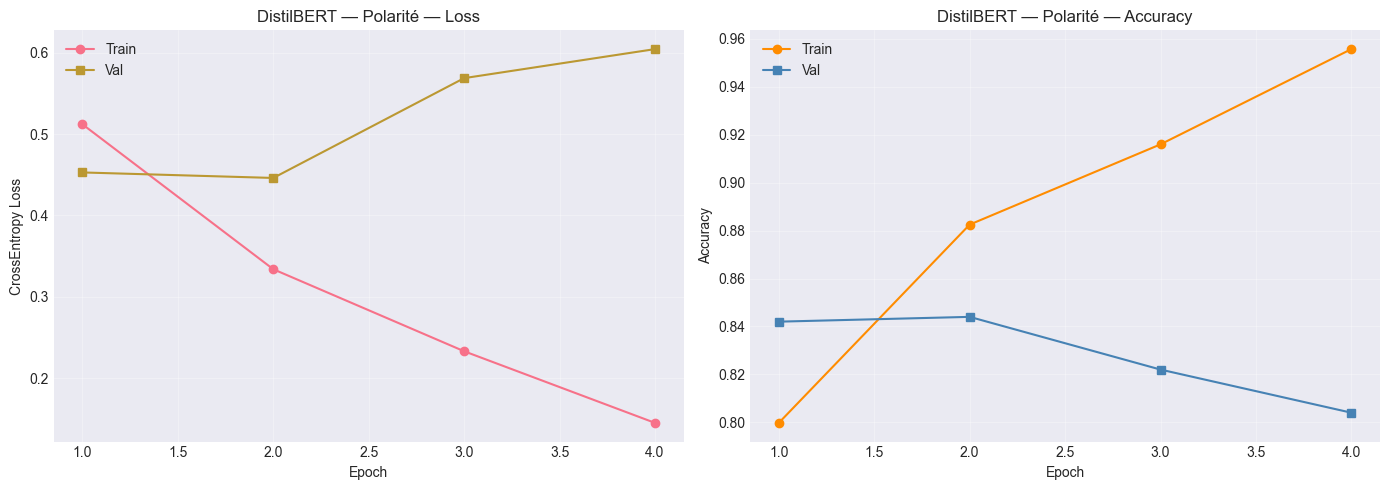


=== DistilBERT — Polarité ===
Accuracy  : 0.8720
F1 Macro  : 0.7444
Precision : 0.7853
Recall    : 0.7229
              precision    recall  f1-score   support

     Négatif       0.88      0.86      0.87       120
      Neutre       0.58      0.35      0.44        51
     Positif       0.89      0.96      0.93       329

    accuracy                           0.87       500
   macro avg       0.79      0.72      0.74       500
weighted avg       0.86      0.87      0.86       500



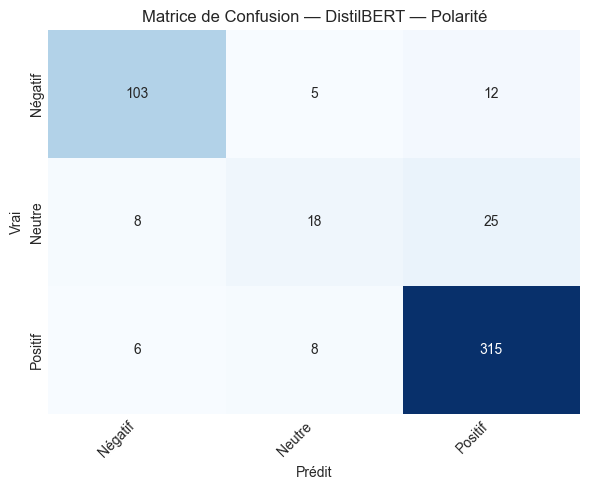

In [9]:
plot_training_curves(history_pol, 'DistilBERT — Polarité', 'distilbert_polarite_curves.png')
acc_pol, f1_pol = evaluate_and_report(
    model_pol, test_pol, ['Négatif', 'Neutre', 'Positif'], 'DistilBERT — Polarité'
)

---
## 6. Tâche 2 : Prédiction du Score (1-5 étoiles)

In [10]:
print("=" * 60)
print("TÂCHE 2 : SCORE (1 à 5 étoiles)")
print("=" * 60)

train_sc, val_sc, test_sc = make_loaders(y_sc_train, y_sc_val, y_sc_test)

model_score = DistilBertClassifier(MODEL_NAME, num_classes=5).to(DEVICE)
model_score, history_score = train_distilbert(model_score, train_sc, val_sc, epochs=EPOCHS, lr=LR, patience=PATIENCE)

TÂCHE 2 : SCORE (1 à 5 étoiles)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Entraînement sur mps pendant 5 epochs...



Epoch 1/5 | Train loss: 1.0560 acc: 0.5730 | Val loss: 0.8500 acc: 0.6460


Epoch 2/5 | Train loss: 0.7672 acc: 0.6845 | Val loss: 0.8709 acc: 0.6460


Epoch 3/5 | Train loss: 0.6157 acc: 0.7580 | Val loss: 0.8860 acc: 0.6680
Early stopping à l'epoch 3.
Entraînement terminé.


Figure saved to: ../../outputs/figures/distilbert_score_curves.png


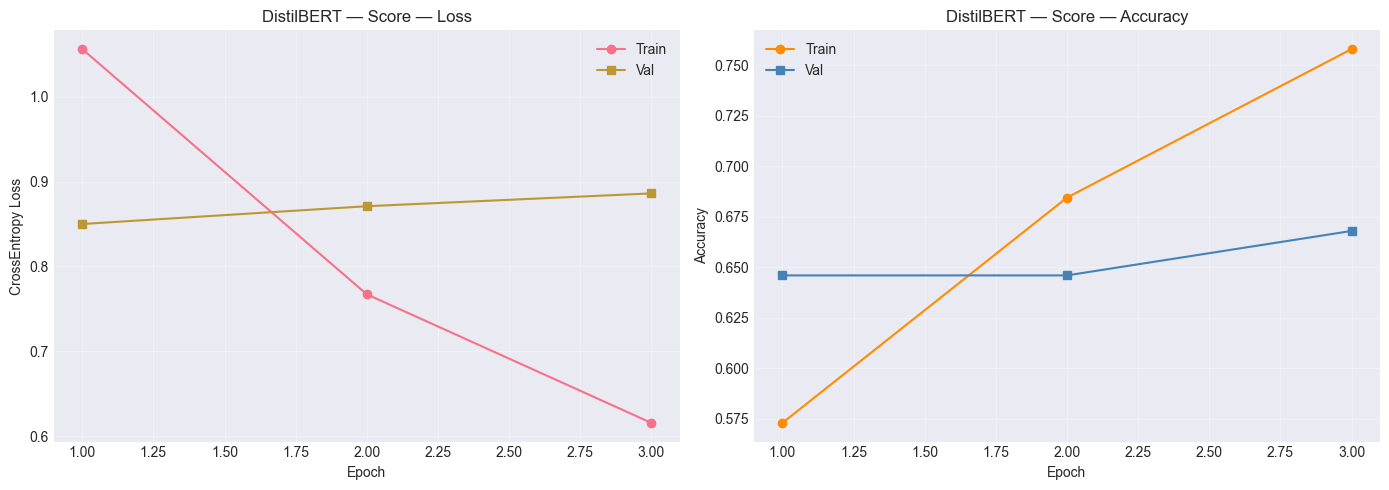


=== DistilBERT — Score ===
Accuracy  : 0.6880
F1 Macro  : 0.5523
Precision : 0.5936
Recall    : 0.5581
              precision    recall  f1-score   support

          1★       0.71      0.93      0.81        74
          2★       0.56      0.20      0.29        46
          3★       0.39      0.39      0.39        51
          4★       0.51      0.38      0.43        93
          5★       0.79      0.89      0.84       236

    accuracy                           0.69       500
   macro avg       0.59      0.56      0.55       500
weighted avg       0.66      0.69      0.66       500



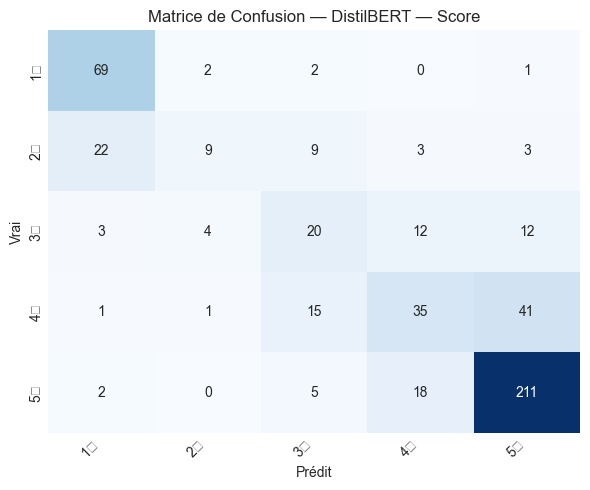

In [11]:
plot_training_curves(history_score, 'DistilBERT — Score', 'distilbert_score_curves.png')
acc_sc, f1_sc = evaluate_and_report(
    model_score, test_sc, [f'{i+1}★' for i in range(5)], 'DistilBERT — Score'
)

---
## 7. Sauvegarde des modèles Fine-tunés

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [12]:
# Sauvegarder le modèle complet (poids + config)
final_model_dir = os.path.join(MODELS_DIR, 'distilbert_finetuned')
os.makedirs(final_model_dir, exist_ok=True)

# Sauvegarder les poids PyTorch
torch.save({
    'model_state_dict': model.state_dict(),
    'model_name':       MODEL_NAME,
    'num_classes':      5,
    'max_length':       MAX_LENGTH,
    'accuracy_test':    float(acc),
    'f1_macro_test':    float(f1)
}, os.path.join(final_model_dir, 'model.pt'))

# Sauvegarder aussi le tokenizer pour faciliter l'inférence
tokenizer.save_pretrained(os.path.join(final_model_dir, 'tokenizer'))

print(f'Modèle sauvegardé dans : {final_model_dir}/')
print(f'  └── model.pt')
print(f'  └── tokenizer/')
print(f'\nPerformance finale (test) | Accuracy: {acc:.4f} | F1 Macro: {f1:.4f}')

NameError: name 'acc' is not defined

final_model_dir = os.path.join(MODELS_DIR, 'distilbert_finetuned')
os.makedirs(final_model_dir, exist_ok=True)

# Sauvegarder les deux modèles
torch.save({
    'model_state_dict': model_pol.state_dict(),
    'model_name': MODEL_NAME,
    'num_classes': 3,
    'max_length': MAX_LENGTH,
    'accuracy_test': float(acc_pol),
    'f1_macro_test': float(f1_pol),
    'task': 'polarity'
}, os.path.join(final_model_dir, 'model_polarity.pt'))

torch.save({
    'model_state_dict': model_score.state_dict(),
    'model_name': MODEL_NAME,
    'num_classes': 5,
    'max_length': MAX_LENGTH,
    'accuracy_test': float(acc_sc),
    'f1_macro_test': float(f1_sc),
    'task': 'score'
}, os.path.join(final_model_dir, 'model_score.pt'))

# Sauvegarder le tokenizer
tokenizer.save_pretrained(os.path.join(final_model_dir, 'tokenizer'))

print(f'Modèles sauvegardés dans : {final_model_dir}/')
print(f'  └── model_polarity.pt')
print(f'  └── model_score.pt')
print(f'  └── tokenizer/')

---
## 8. Résumé des performances

In [ ]:
comparison = pd.DataFrame({
    'Tâche': ['Polarité (3 classes)', 'Score (1-5)'],
    'Accuracy': [acc_pol, acc_sc],
    'F1 Macro': [f1_pol, f1_sc],
})
print("=== RÉSUMÉ DISTILBERT FINE-TUNING ===")
display(comparison)

print(f"\nArchitecture : DistilBERT → [CLS] → Dense(768→256) → Dense(256→N)")
print(f"Optimiseur   : AdamW (lr={LR}, weight_decay=0.01)")
print(f"Échantillon  : {SAMPLE_SIZE} avis")